## LLM-Enhanced Topic-Modeling and Sentiment Analysis

## Topic Modeling

In [7]:
import requests
import pandas as pd

# Qwen API URL and headers
api_key = "sk-817b52d09f4b470eb444be11281420b9"
API_URL = "https://dashscope.aliyuncs.com/compatible-mode/v1/chat/completions"
HEADERS = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

# Define few-shot learning examples (covering all seed topics)
few_shot_examples = [
    {"role": "system", "content": """You are a sentiment and topic analysis model. 
    Your task is to analyze the sentiment and identify the **most relevant topic** from the provided text.
    For sentiment, classify it into one of the following categories:
    - Positive: The text conveys a positive or favorable sentiment.
    - Negative: The text conveys a negative or unfavorable sentiment.
    - Neutral: The text is neither strongly positive nor negative.

    For topics, select only **one most relevant topic** from the following categories:
    - Diplomatic Relations: Describes political or diplomatic relations between countries.
    - Trade and Economy (Competition): Focuses on trade rivalry, economic conflicts, tariffs, etc.
    - Economy Cooperation: Describes economic cooperation, trade agreements, and positive economic interactions.
    - National Defense and Military: Discusses military issues, defense policies, and international security.
    - COVID-19 Response: Relates to responses to the COVID-19 pandemic, including handling of the outbreak and international cooperation.
    - Education (STEM, Collaboration): Involves education, especially science, technology, engineering, and mathematics, and international collaboration in these fields.
    - Technological Innovation (AI, 5G, Digital Governance): Focuses on advances in technology, digital governance, and cybersecurity.
    - Democracy and Human Rights in China (Political Repression): Addresses issues related to democracy, human rights, and political repression in China.

    Please provide your output in the following format:
    Sentiment: [sentiment]
    Topic: [most relevant topic]
    Keywords: [comma-separated list of important keywords (up to 5)]"""}
]

# Function to analyze sentiment and topic
def analyze_sentiment_and_topic(text):
    payload = {
        "model": "qwen-plus",
        "messages": few_shot_examples + [{"role": "user", "content": text}]
    }
    
    try:
        response = requests.post(API_URL, headers=HEADERS, json=payload)
        
        if response.status_code == 200:
            try:
                response_json = response.json()
                print("Response JSON:", response_json)  # For debugging

                content = response_json.get('choices', [{}])[0].get('message', {}).get('content', '')
                
                sentiment = "Unknown"
                topic = "Unknown"
                keywords = []
                
                if content:
                    lines = content.split('\n')
                    for line in lines:
                        if line.startswith("Sentiment:"):
                            sentiment = line.replace("Sentiment:", "").strip()
                        elif line.startswith("Topic:"):
                            topic = line.replace("Topic:", "").strip()
                        elif line.startswith("Keywords:"):
                            keywords = line.replace("Keywords:", "").strip().split(', ')

                keywords = keywords[:5]
                return sentiment, topic, keywords
            
            except Exception as e:
                print(f"Error parsing response JSON: {e}")
                return "Unknown", "Unknown", []
        else:
            print(f"Error: Received status code {response.status_code}")
            return "Unknown", "Unknown", []
    
    except Exception as e:
        print(f"Request failed: {e}")
        return "Unknown", "Unknown", []

# Read the input Excel file
df = pd.read_excel('china_paragraphs_with_metadata.xlsx')

# Initialize new columns
df['sentiment'] = None
df['topic'] = None
df['keywords'] = None

# Set output file name
output_file = 'output_china_paragraphs_with_metadata.xlsx'

# Process each row and save immediately
for i, row in df.iterrows():
    transcript = row['china_paragraph']
    sentiment, topic, keywords = analyze_sentiment_and_topic(transcript)
    
    # Update the DataFrame
    df.at[i, 'sentiment'] = sentiment
    df.at[i, 'topic'] = topic
    df.at[i, 'keywords'] = ', '.join(keywords) if keywords else 'Unknown'
    
    # Save the DataFrame after each update
    df.to_excel(output_file, index=False)

print("All rows processed and saved.")


Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: National Defense and Military  \nKeywords: United Nations, conflict, Korea, aggressor, military forces'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 582, 'completion_tokens': 26, 'total_tokens': 608, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created': 1745137555, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-a3562b7b-7d8e-987c-8672-74dfcad544ef'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: National Defense and Military  \nKeywords: conflict, Korea, aggressor, war, military'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 582, 'completion_tokens': 24, 'total_tokens': 606, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created': 1745137560, 'system_fingerprint': Non

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Negative  \nTopic: National Defense and Military  \nKeywords: defense, United Nations, Red China, military strength, prestige'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 717, 'completion_tokens': 26, 'total_tokens': 743, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created': 1745137646, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-f091638a-46fc-91c1-b382-754e2fbd0813'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: Diplomatic Relations  \nKeywords: President Eisenhower, peace, Communists, Formosa, Quemoy and Matsu'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 644, 'completion_tokens': 30, 'total_tokens': 674, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created': 1745137652, 'sys

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: Economy Cooperation  \nKeywords: economic ties, free nations, trade expansion, protectionism, developing nations'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 738, 'completion_tokens': 26, 'total_tokens': 764, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745137733, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-2d963759-2250-9b20-980a-75d75f6b04fb'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: National Defense and Military  \nKeywords: national interest, security, alliances, balance of power, foreign policy'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 835, 'completion_tokens': 27, 'total_tokens': 862, 'prompt_tokens_details': {'cached_tokens': 0}}, 'crea

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: National Defense and Military  \nKeywords: nuclear powers, test ban treaty, Soviet interest, nuclear spread, Red China'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 613, 'completion_tokens': 29, 'total_tokens': 642, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745137831, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-3c341d7c-d891-9dea-bfda-9a49b96066e1'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: Diplomatic Relations  \nKeywords: Soviet Government, Kremlin, Moscow, Communist China, nuclear device'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 557, 'completion_tokens': 25, 'total_tokens': 582, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created': 17

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Negative  \nTopic: National Defense and Military  \nKeywords: Viet-Nam, war, communism, defense, American power'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 570, 'completion_tokens': 26, 'total_tokens': 596, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745137916, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-6a3f8103-909e-998f-9cab-407d6056d5a4'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: Trade and Economy (Competition)  \nKeywords: tariffs, trade, Eastern Europe, national independence, Vietnam'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 609, 'completion_tokens': 28, 'total_tokens': 637, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created': 1745137922, 'system_f

...

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Negative  \nTopic: Trade and Economy (Competition)  \nKeywords: blackouts, California, economy, shutdown, depression'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 562, 'completion_tokens': 27, 'total_tokens': 589, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created': 1745139627, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-149dff09-2ace-98fb-a086-dbf717f36b90'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Positive  \nTopic: Trade and Economy (Competition)  \nKeywords: numbers, taxes, China, economy, tariffs'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 555, 'completion_tokens': 26, 'total_tokens': 581, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745139634, 'system_fingerprint': None

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Negative  \nTopic: Trade and Economy (Competition)  \nKeywords: tariffs, Paris Climate Accord, China, economy, competition'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 572, 'completion_tokens': 28, 'total_tokens': 600, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745139736, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-88271811-56c3-91fd-ab70-7a6ff12ccf29'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Negative  \nTopic: Trade and Economy (Competition)  \nKeywords: Paris Climate Accord, China, rules, WTO, Biden'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 545, 'completion_tokens': 28, 'total_tokens': 573, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745139743, 'system_fin

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Positive  \nTopic: Trade and Economy (Competition)  \nKeywords: tariffs, jobs, China, Made in America, medical supplies'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 527, 'completion_tokens': 29, 'total_tokens': 556, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745139841, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-6d63a872-34c1-9a2f-8f01-be7c00f6e04b'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Negative  \nTopic: Trade and Economy (Competition)  \nKeywords: tariffs, jobs, China, Made in America, virus'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 523, 'completion_tokens': 28, 'total_tokens': 551, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745139849, 'system_fingerpr

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Negative  \nTopic: National Defense and Military  \nKeywords: Afghanistan, Taliban, U.S. military, political leaders, strategic competitors'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 682, 'completion_tokens': 28, 'total_tokens': 710, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745139937, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-eee5d232-d679-95ee-ab57-64558ca5baab'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: National Defense and Military  \nKeywords: ISIS-K, national interest, competition, China, cyberattacks'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 584, 'completion_tokens': 26, 'total_tokens': 610, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created'

Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Positive  \nTopic: National Defense and Military  \nKeywords: Ukraine, NATO, China, Indo-Pacific, competition'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 796, 'completion_tokens': 24, 'total_tokens': 820, 'prompt_tokens_details': {'cached_tokens': 256}}, 'created': 1745140030, 'system_fingerprint': None, 'model': 'qwen-plus', 'id': 'chatcmpl-afcaafbe-c52e-9446-bc35-36bd47e474a7'}
Response JSON: {'choices': [{'message': {'role': 'assistant', 'content': 'Sentiment: Neutral  \nTopic: National Defense and Military  \nKeywords: NATO, Ukraine, China, Indo-Pacific, military coercion'}, 'finish_reason': 'stop', 'index': 0, 'logprobs': None}], 'object': 'chat.completion', 'usage': {'prompt_tokens': 798, 'completion_tokens': 25, 'total_tokens': 823, 'prompt_tokens_details': {'cached_tokens': 0}}, 'created': 1745140036, 'system_fingerprint': 

### extract year

In [16]:
import pandas as pd

# Read the Excel file containing 'china_paragraph'
df = pd.read_excel('output_china_paragraphs_with_metadata.xlsx')

# Ensure the 'date' column is properly converted to datetime format, handling invalid dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract the year from the 'date' column
df['year'] = df['date'].dt.year.astype('Int64')

# Save the updated DataFrame with the 'year' column
df.to_excel('output_china_paragraphs_with_metadata_with_year.xlsx', index=False)

# Check if the 'year' column has been correctly added
print(df['year'].head())


0    1951
1    1951
2    1951
3    1952
4    1953
Name: year, dtype: Int64


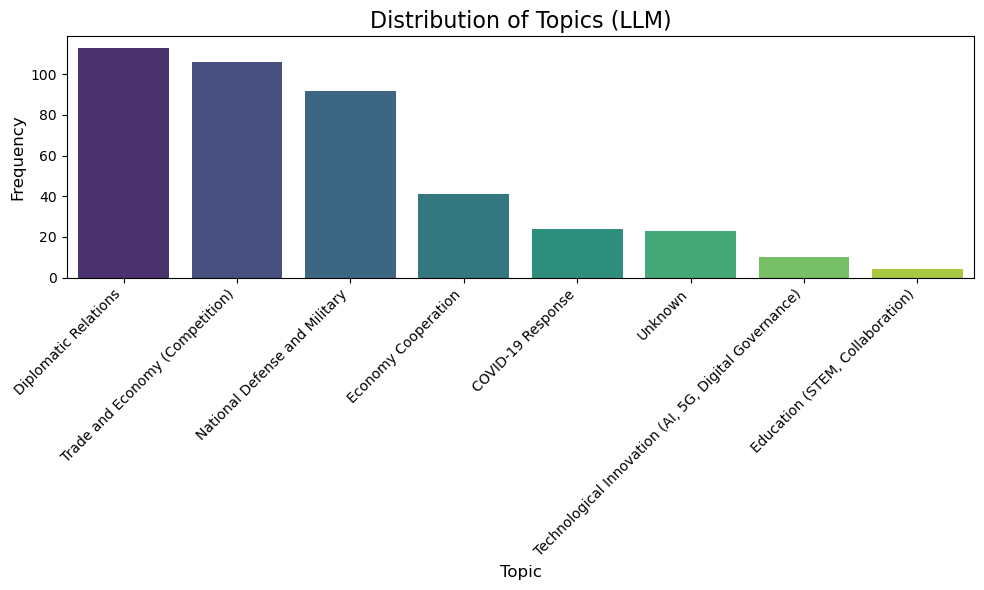

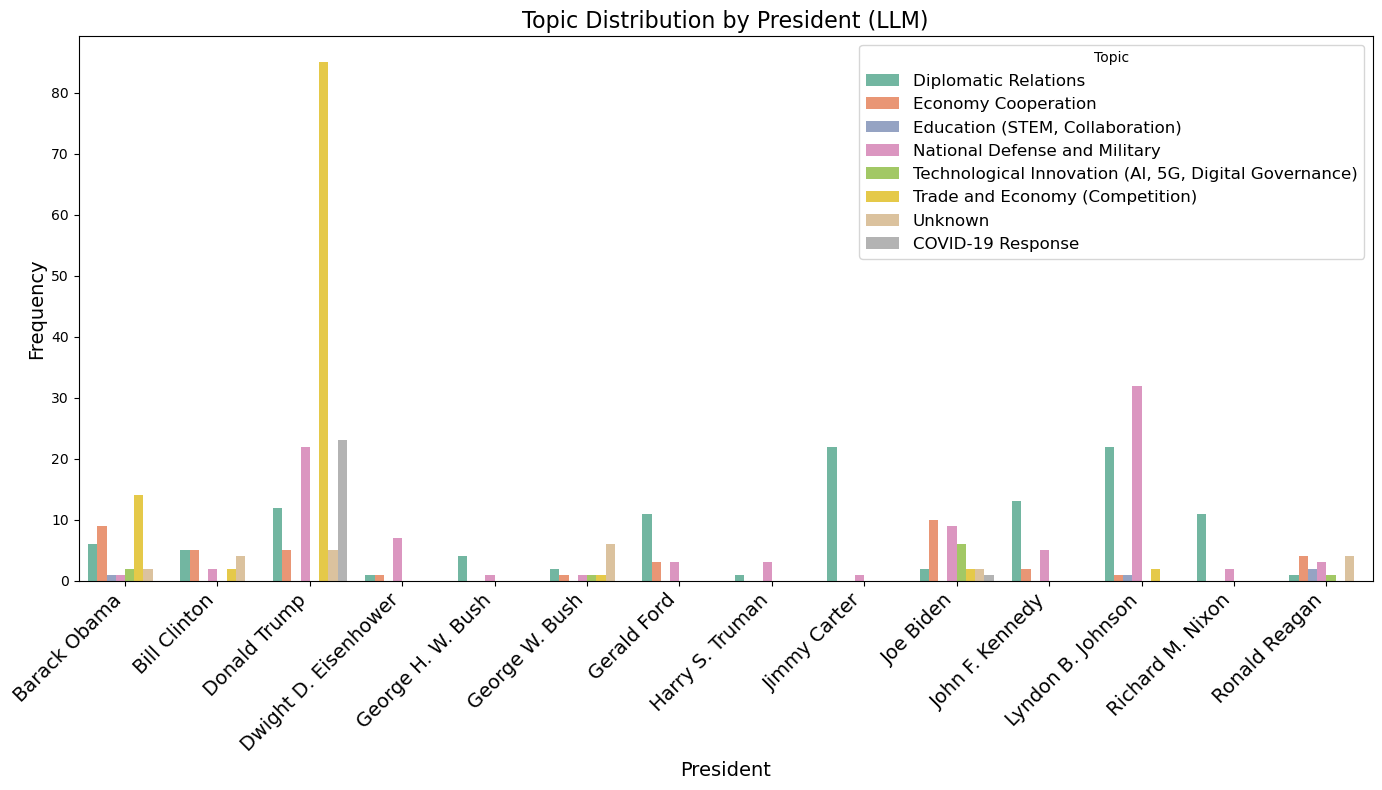

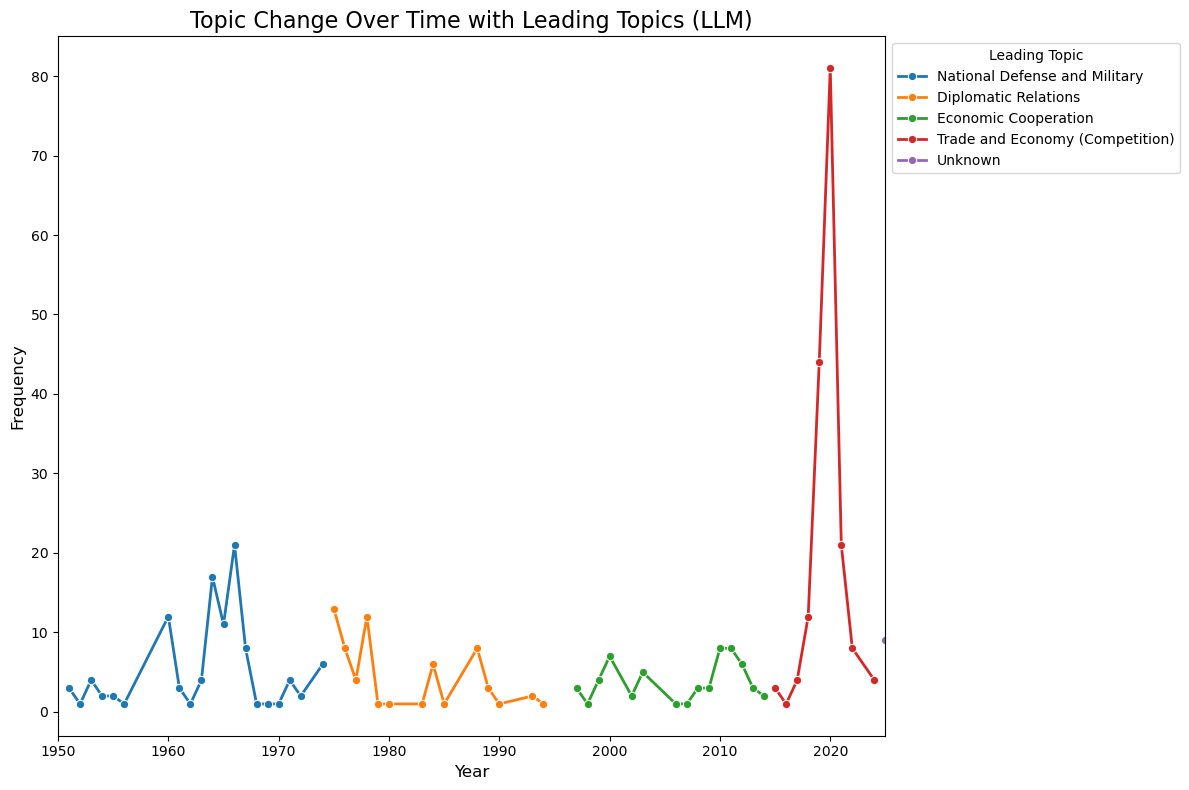

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_excel('output_china_paragraphs_with_metadata_with_year.xlsx')

# Ensure 'year' is of integer type
df['year'] = df['year'].astype('Int64')

# ========================================
# 1. Plot overall topic distribution
# ========================================
topic_counts = df['topic'].value_counts().reset_index()
topic_counts.columns = ['Topic', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=topic_counts, x='Topic', y='Count', hue='Topic', palette='viridis', legend=False)
plt.title('Distribution of Topics (LLM)', fontsize=16)
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('topic_distribution_overall.png', dpi=300)
plt.show()


# ========================================
# 2. Plot topic distribution by president
# ========================================
president_topic_counts = df.groupby(['president', 'topic']).size().reset_index(name='count')

plt.figure(figsize=(14, 8))
sns.barplot(data=president_topic_counts, x='president', y='count', hue='topic', palette='Set2')
plt.title('Topic Distribution by President (LLM)', fontsize=16)
plt.xlabel('President', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45, ha='right',fontsize=14)
plt.legend(title='Topic', bbox_to_anchor=(1, 1),fontsize=12)
plt.tight_layout()

#Save the figure
plt.savefig('topic_distribution_by_president.png', dpi=300)
plt.show()

# ========================================
# 3. Plot how leading topics change over time
# ========================================

# Define the leading topic for each time period
def assign_leading_topic(year):
    if pd.isna(year) or year == 0:
        return 'Unknown'
    if year < 1975:
        return 'National Defense and Military'
    elif 1975 <= year < 1995:
        return 'Diplomatic Relations'
    elif 1995 <= year < 2015:
        return 'Economic Cooperation'
    elif 2015 <= year < 2025:
        return 'Trade and Economy (Competition)'
    else:
        return 'Unknown'

# Apply the function to assign leading topics
df['leading_topic'] = df['year'].apply(assign_leading_topic)

# Group by year and leading topic
year_leading_topic_counts = df.groupby(['year', 'leading_topic']).size().reset_index(name='count')

# Plot the trend of leading topics over time
plt.figure(figsize=(12, 8))
sns.lineplot(data=year_leading_topic_counts, x='year', y='count', hue='leading_topic', marker='o', lw=2)

# Set x-axis range
plt.xlim(1950, 2025)

# Ensure y-axis has integer ticks
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Add titles and labels
plt.title('Topic Change Over Time with Leading Topics (LLM)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title='Leading Topic', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
# Save the figure
#plt.savefig('topic_change_over_time.png', dpi=300)
plt.show()

/var/folders/_w/fbnsh7f96ln6s86184sqfml80000gn/T/ipykernel_8889/3728861109.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(topic_order))


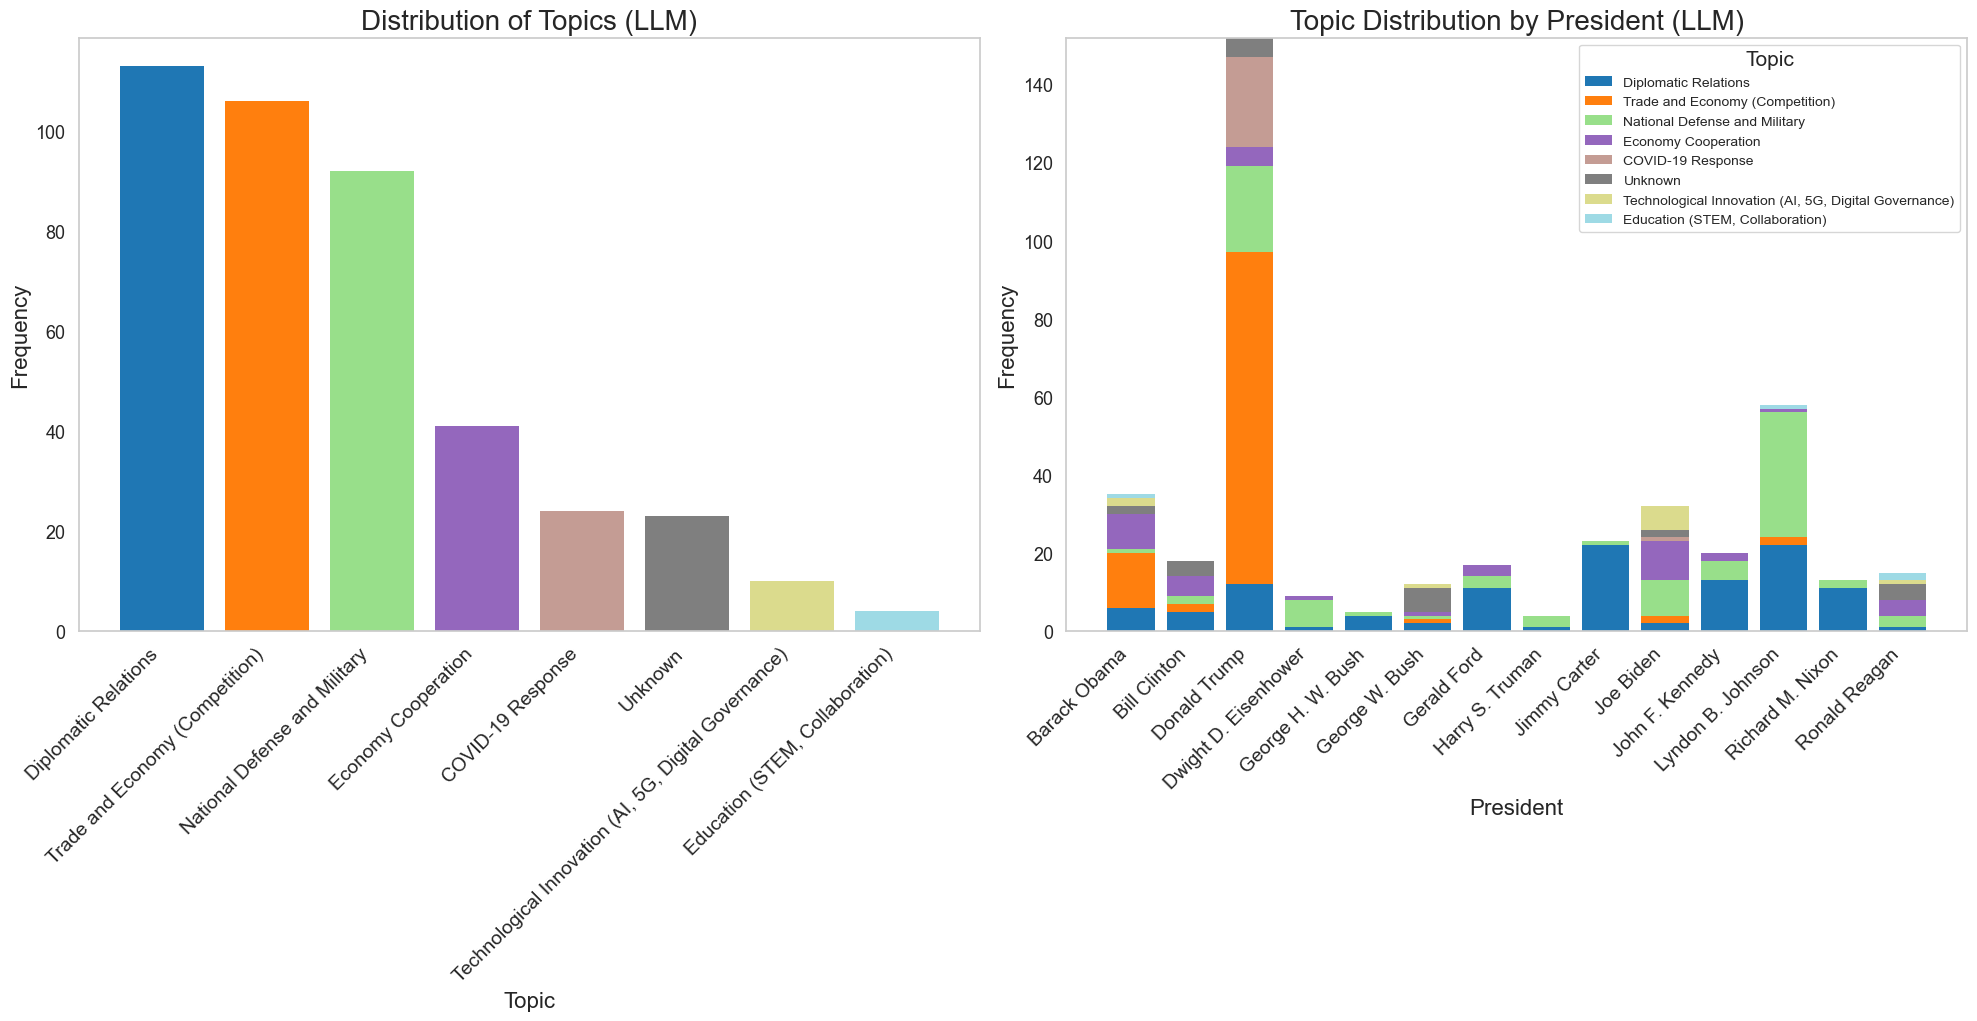

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load data
df = pd.read_excel('output_china_paragraphs_with_metadata_with_year.xlsx')

# Drop rows with missing data
df = df[df['topic'].notna()]
df = df[df['president'].notna()]

# Prepare topic order by total frequency
topic_counts = df['topic'].value_counts()
topic_order = topic_counts.index.tolist()

# Color mapping
cmap = cm.get_cmap('tab20', len(topic_order))
color_dict = {topic: cmap(i) for i, topic in enumerate(topic_order)}

# -------- Plot 1 & 2 --------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# -------- Plot 1: Overall Topic Distribution --------
x1 = np.arange(len(topic_order))
y1 = [topic_counts[topic] for topic in topic_order]
bars1 = axes[0].bar(x1, y1, color=[color_dict[topic] for topic in topic_order], edgecolor='none')

axes[0].set_title('Distribution of Topics (LLM)', fontsize=20)
axes[0].set_xlabel('Topic', fontsize=16)
axes[0].set_ylabel('Frequency', fontsize=16)
axes[0].set_xticks(x1)
axes[0].set_xticklabels(topic_order, rotation=45, ha='right', fontsize=14)
axes[0].tick_params(axis='y', labelsize=13)
axes[0].grid(False)  # ❌ Remove grid lines
for spine in axes[0].spines.values():
    spine.set_visible(True)  

# -------- Plot 2: Topic Distribution by President --------
president_topic = df.groupby(['president', 'topic']).size().unstack(fill_value=0)
president_topic = president_topic[topic_order]

x2 = np.arange(len(president_topic))
bar_width = 0.8
bottom = np.zeros(len(president_topic))

for topic in topic_order:
    heights = president_topic[topic].values
    axes[1].bar(x2, heights, bottom=bottom, color=color_dict[topic], label=topic, edgecolor='none', width=bar_width)
    bottom += heights

axes[1].set_title('Topic Distribution by President (LLM)', fontsize=20)
axes[1].set_xlabel('President', fontsize=16)
axes[1].set_ylabel('Frequency', fontsize=16)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(president_topic.index, rotation=45, ha='right', fontsize=14)
axes[1].tick_params(axis='y', labelsize=13)
axes[1].grid(False)  # ❌ Remove grid lines
for spine in axes[1].spines.values():
    spine.set_visible(True)  

# Legend placed inside Plot 2 (upper right)
axes[1].legend(
    loc='upper right',
    fontsize=10,
    title='Topic',
    title_fontsize=15,

    ncol=1
)

# Layout adjustment
plt.tight_layout(rect=[0, 0, 1, 1])
plt.subplots_adjust(bottom=0.2)
plt.savefig('topic_distribution_cleaned.png', dpi=300,bbox_inches='tight')
plt.show()


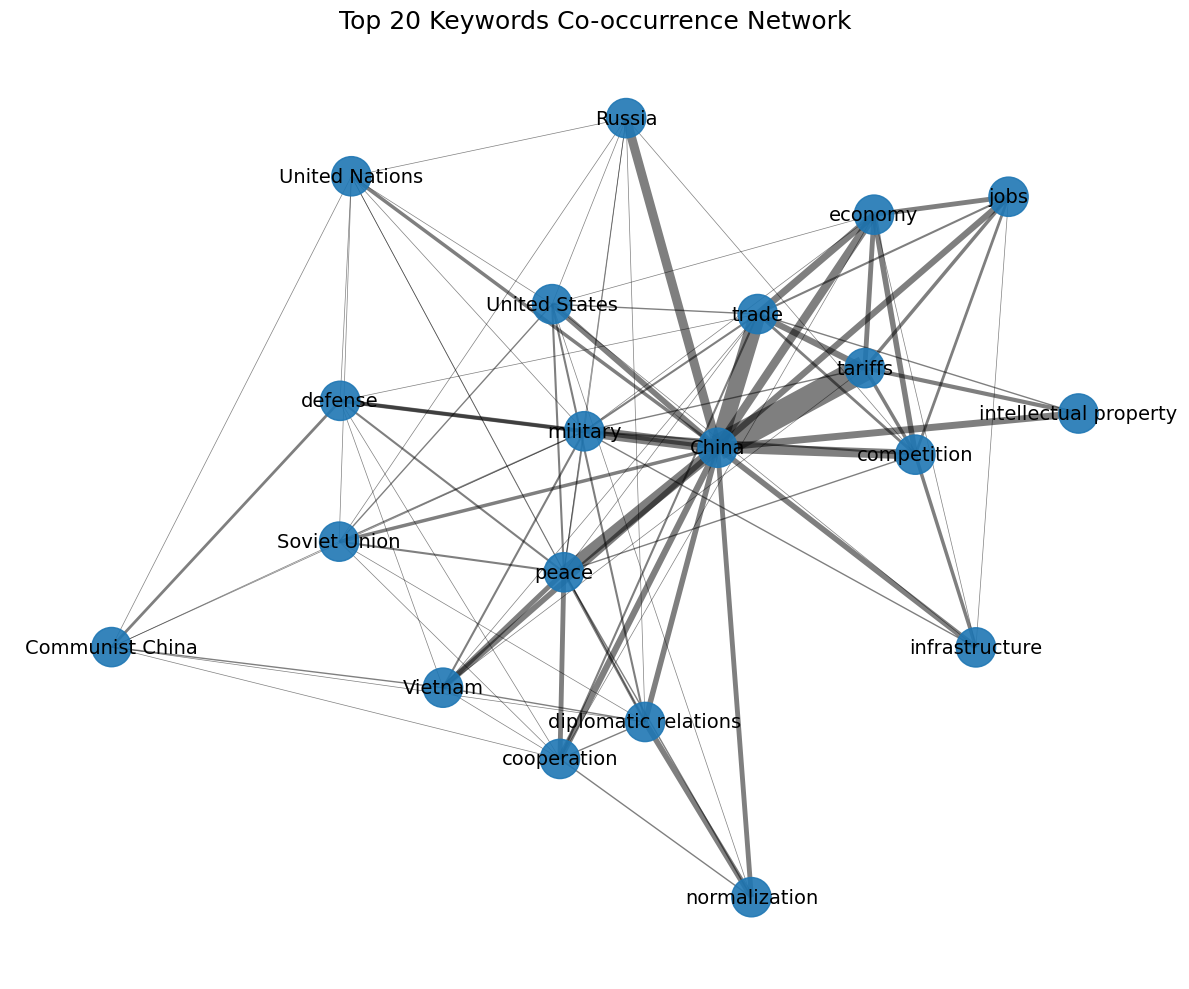

In [33]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# Load the data
df = pd.read_excel('output_china_paragraphs_with_metadata_with_year.xlsx')

# Ensure 'year' is of Int64 type
df['year'] = df['year'].astype('Int64')

# Assume 'keywords' column is a comma-separated string
df['keywords'] = df['keywords'].apply(lambda x: [kw.strip() for kw in x.split(',')] if isinstance(x, str) else [])

# Remove rows where topic is 'Unknown'
df = df[df['topic'] != 'Unknown'].reset_index(drop=True)

# Count the frequency of all keywords
all_keywords = [kw for kws in df['keywords'] for kw in kws]
keyword_counts = Counter(all_keywords)

# Select the top 20 most frequent keywords
top_keywords = set([kw for kw, _ in keyword_counts.most_common(20)])

# Build the graph: only keep co-occurrence relations between top keywords
G = nx.Graph()

for idx, row in df.iterrows():
    keywords = set(row['keywords'])
    topic = row['topic']
    
    # Only keep keywords in the top_keywords list
    filtered_keywords = keywords.intersection(top_keywords)
    
    if len(filtered_keywords) > 1:
        for kw1, kw2 in combinations(sorted(filtered_keywords), 2):
            if G.has_edge(kw1, kw2):
                G[kw1][kw2]['weight'] += 1
            else:
                G.add_edge(kw1, kw2, weight=1)
    
    # Assign topic labels to nodes
    for kw in filtered_keywords:
        if not G.has_node(kw):
            G.add_node(kw, topic=topic)

# Plotting the network
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

# Set all nodes to blue
node_colors = ['#1f77b4'] * len(G.nodes())

# Draw the network
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=[w*0.5 for w in weights], alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=14)

plt.title('Top 20 Keywords Co-occurrence Network', fontsize=18)
plt.axis('off')
plt.tight_layout()

# Save the figure and display it
plt.savefig('all_topics_keywords_network_blue.png', dpi=300)
plt.show()


## Sentiment analysis

## 1.By president

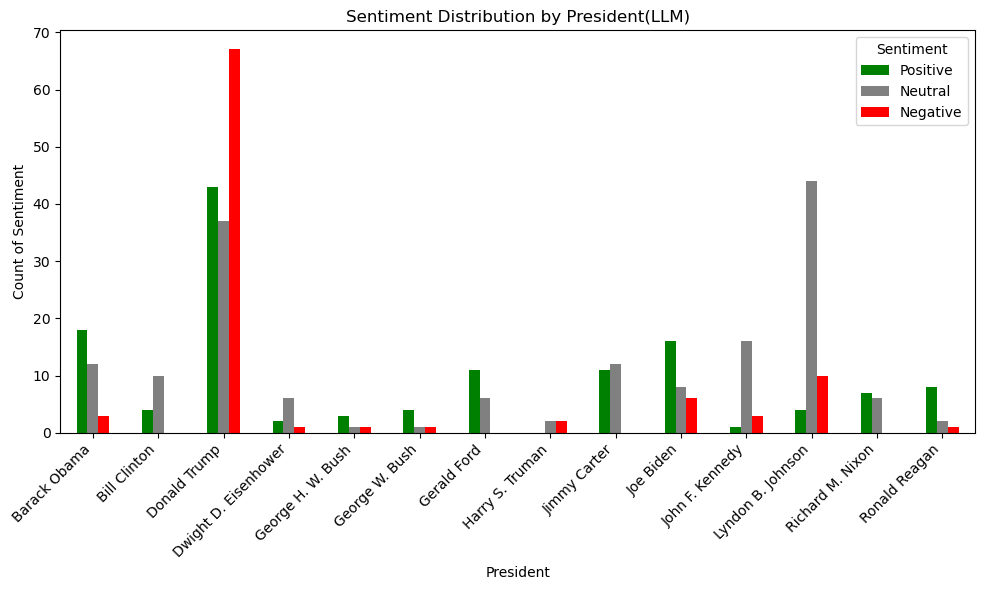

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel('output_china_paragraphs_with_metadata.xlsx')

# Remove 'unknown' sentiment rows
df = df[df['sentiment'] != 'unknown']

# Keep only expected sentiments
valid_sentiments = ['Positive', 'Neutral', 'Negative']
df = df[df['sentiment'].isin(valid_sentiments)]

# Group by president and sentiment
president_sentiment_counts = df.groupby(['president', 'sentiment']).size().unstack(fill_value=0)

# Reorder columns to match color mapping
president_sentiment_counts = president_sentiment_counts[['Positive', 'Neutral', 'Negative']]

# Plot with correct color mapping
color_mapping = ['green', 'gray', 'red']
president_sentiment_counts.plot(kind='bar', figsize=(10, 6), color=color_mapping)

# Labels and legend
plt.title('Sentiment Distribution by President(LLM)')
plt.xlabel('President')
plt.ylabel('Count of Sentiment')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Sentiment")
plt.tight_layout()

# Save the figure before showing it
plt.savefig('sentiment_by_president.png', dpi=300)


plt.show()


## 2. By Topic

/var/folders/_w/fbnsh7f96ln6s86184sqfml80000gn/T/ipykernel_3652/2596723668.py:44: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


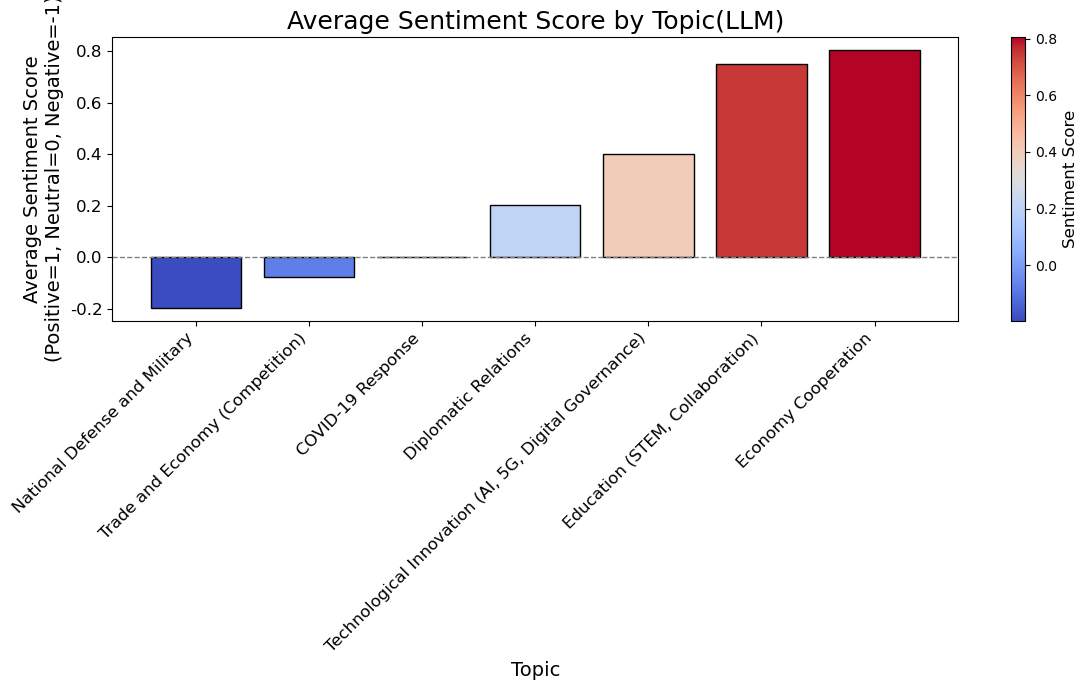

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load the data
df = pd.read_excel('output_china_paragraphs_with_metadata.xlsx')

# Remove entries with unknown sentiment
df = df[df['sentiment'] != 'unknown']

# Map sentiment labels to numerical scores
sentiment_score_map = {
    'Positive': 1,
    'Neutral': 0,
    'Negative': -1
}
df['sentiment_score'] = df['sentiment'].map(sentiment_score_map)

# Calculate the average sentiment score for each topic
topic_sentiment_score = df.groupby('topic')['sentiment_score'].mean().sort_values()

# Set up color mapping (from red to blue) based on normalized scores
norm = plt.Normalize(topic_sentiment_score.min(), topic_sentiment_score.max())
colors = cm.coolwarm(norm(topic_sentiment_score.values))  # Alternatively, use plt.cm.RdYlGn

# Plot the bar chart
plt.figure(figsize=(12, 7))
bars = plt.bar(topic_sentiment_score.index, topic_sentiment_score.values, color=colors, edgecolor='black')

# Add a horizontal line at y=0
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Set the title and axis labels
plt.title('Average Sentiment Score by Topic(LLM)', fontsize=18)
plt.xlabel('Topic', fontsize=14)
plt.ylabel('Average Sentiment Score\n(Positive=1, Neutral=0, Negative=-1)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a colorbar (optional)
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Sentiment Score', fontsize=12)

# Save and display the figure
plt.tight_layout()
plt.savefig('colored_sentiment_score_by_topic.png', dpi=300)
plt.show()


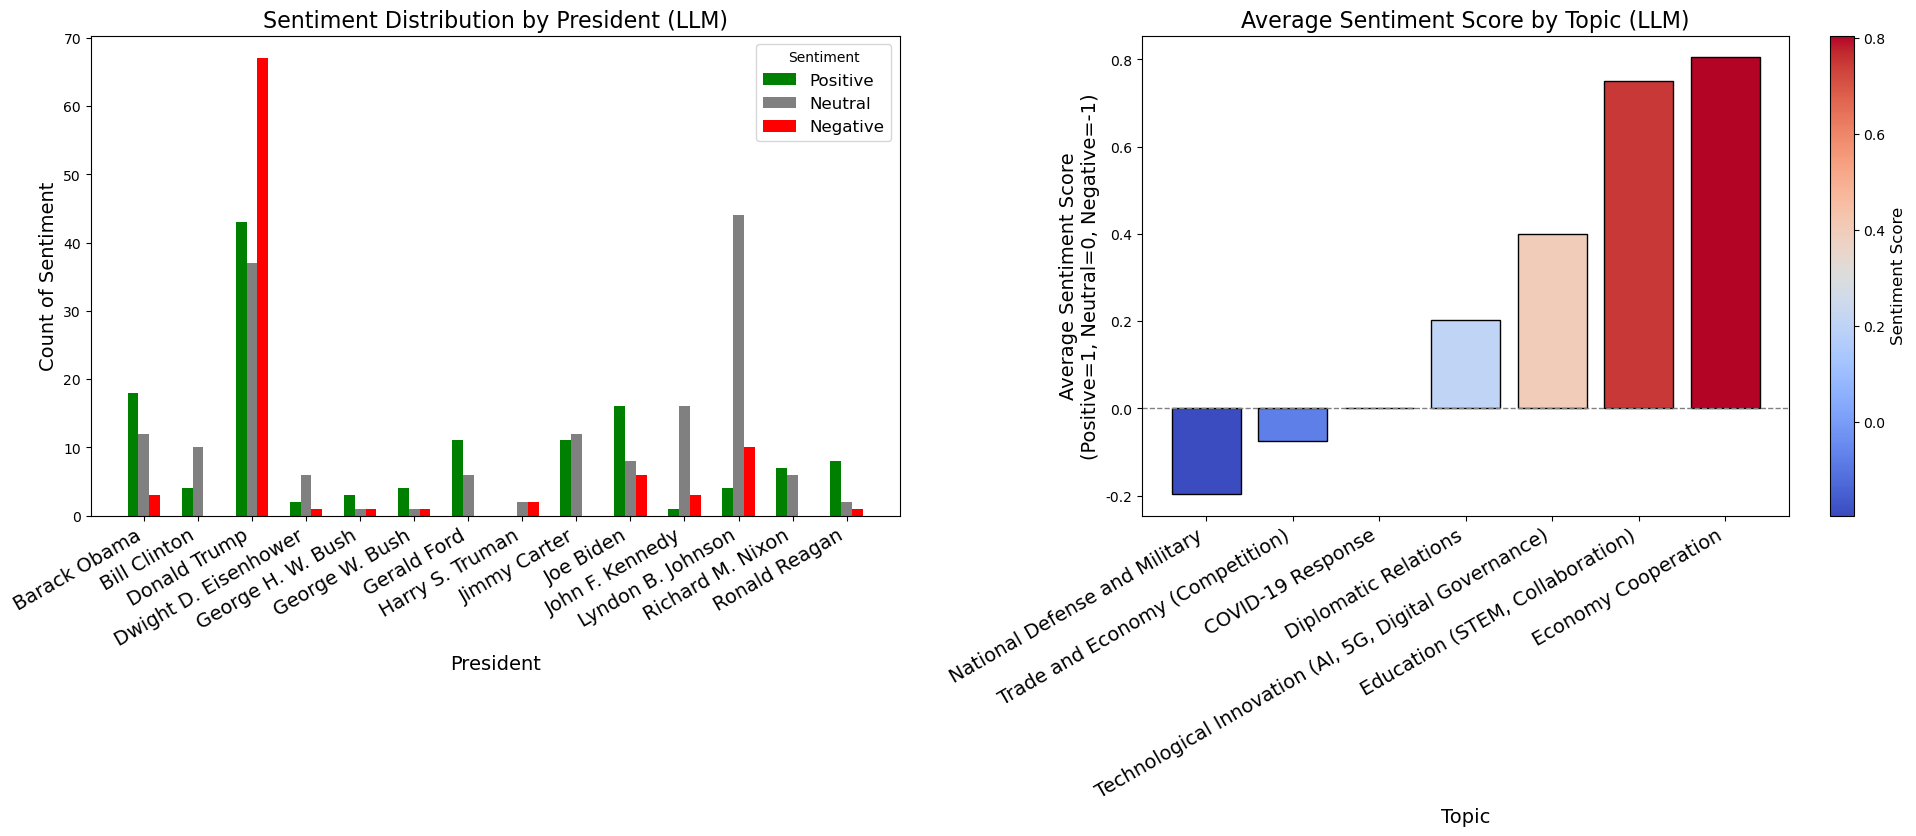

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load data
df = pd.read_excel('output_china_paragraphs_with_metadata.xlsx')

# Remove unknown sentiments
df = df[df['sentiment'] != 'unknown']
df = df[df['sentiment'].isin(['Positive', 'Neutral', 'Negative'])]

# Group by president and sentiment
president_sentiment_counts = df.groupby(['president', 'sentiment']).size().unstack(fill_value=0)
president_sentiment_counts = president_sentiment_counts[['Positive', 'Neutral', 'Negative']]

# Map sentiment to numerical scores
df['sentiment_score'] = df['sentiment'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})
topic_sentiment_score = df.groupby('topic')['sentiment_score'].mean().sort_values()

# Normalize color range
norm = plt.Normalize(topic_sentiment_score.min(), topic_sentiment_score.max())
colors = cm.coolwarm(norm(topic_sentiment_score.values))

# Set up side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# -------- Plot 1: Sentiment Distribution by President --------
presidents = list(president_sentiment_counts.index)
x_pos = np.arange(len(presidents))
bar_width = 0.2
sentiments = ['Positive', 'Neutral', 'Negative']
colors_bar = ['green', 'gray', 'red']

# Draw bars manually to control positioning
for i, sentiment in enumerate(sentiments):
    ax1.bar(x_pos + i * bar_width,
            president_sentiment_counts[sentiment].values,
            width=bar_width,
            label=sentiment,
            color=colors_bar[i])

# Set x-axis labels centered under grouped bars
ax1.set_xticks(x_pos + bar_width)
ax1.set_xticklabels(presidents, rotation=30, ha='right', fontsize=14)  # Enlarged font size
ax1.set_title('Sentiment Distribution by President (LLM)', fontsize=16)
ax1.set_xlabel('President', fontsize=14)
ax1.set_ylabel('Count of Sentiment', fontsize=14)
ax1.legend(title='Sentiment', fontsize=12)

# -------- Plot 2: Average Sentiment Score by Topic --------
topics = topic_sentiment_score.index.tolist()
x_pos2 = np.arange(len(topics))

bars = ax2.bar(x_pos2, topic_sentiment_score.values, color=colors, edgecolor='black')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)

ax2.set_xticks(x_pos2)
ax2.set_xticklabels(topics, rotation=30, ha='right', fontsize=14)  # Enlarged font size
ax2.set_title('Average Sentiment Score by Topic (LLM)', fontsize=16)
ax2.set_xlabel('Topic', fontsize=14)
ax2.set_ylabel('Average Sentiment Score\n(Positive=1, Neutral=0, Negative=-1)', fontsize=14)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2)
cbar.set_label('Sentiment Score', fontsize=12)

# Adjust layout to avoid clipping
plt.subplots_adjust(left=0.05, right=0.98, top=0.9, bottom=0.3, wspace=0.3)

# Save figure with all labels visible
plt.savefig('combined_sentiment_analysis_corrected.png', dpi=300, bbox_inches='tight')
plt.show()


## Donald Trump Sentiment Over Time

Data for Donald Trump: 152 rows.
Donald Trump's sentiment counts:
sentiment
Negative    67
Positive    43
Neutral     37
Unknown      5
Name: count, dtype: int64


/var/folders/_w/fbnsh7f96ln6s86184sqfml80000gn/T/ipykernel_3652/1282688866.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trump.loc[:, 'sentiment_score'] = df_trump['sentiment'].map(sentiment_score_map)


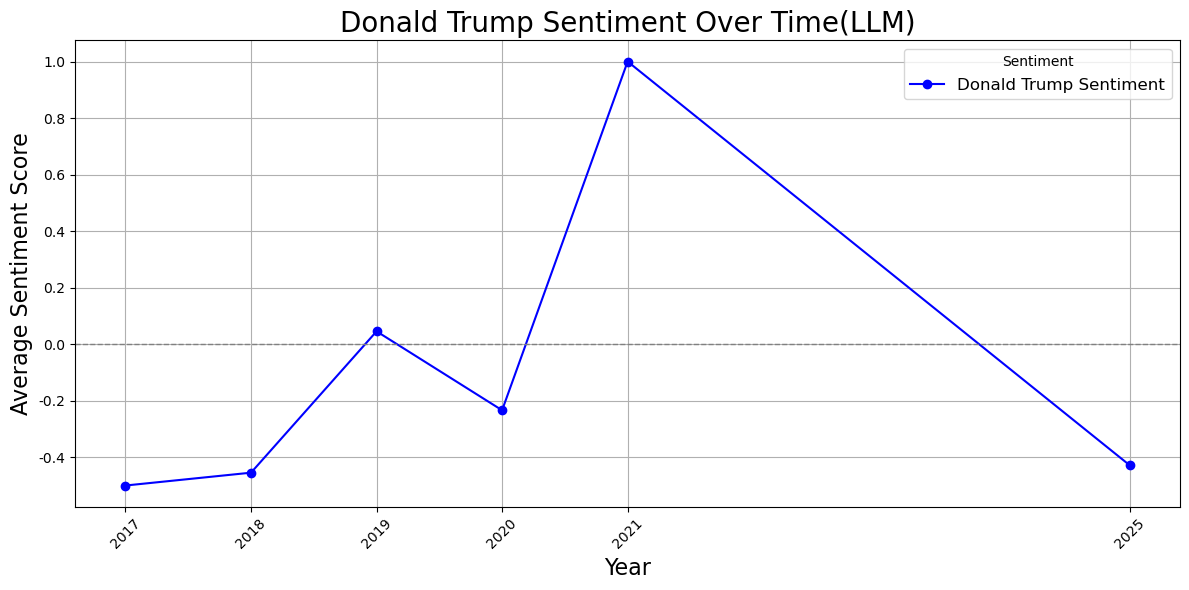

In [19]:
import pandas as pd

# Read the Excel file containing the china_paragraph data
df = pd.read_excel('output_china_paragraphs_with_metadata_with_year.xlsx')

# Remove entries with unknown sentiment
df = df[df['sentiment'] != 'unknown']

# Filter the data for Donald Trump
df_trump = df[df['president'] == 'Donald Trump']

# Check if the filtered dataframe is empty
if df_trump.empty:
    print("No data found for Donald Trump.")
else:
    print(f"Data for Donald Trump: {len(df_trump)} rows.")

# Display the count of each sentiment category
sentiment_counts = df_trump['sentiment'].value_counts()
print("Donald Trump's sentiment counts:")
print(sentiment_counts)

# Map sentiment labels to numerical scores
sentiment_score_map = {
    'Positive': 1,
    'Neutral': 0,
    'Negative': -1
}

# Use .loc to modify the sentiment_score column and avoid SettingWithCopyWarning
df_trump.loc[:, 'sentiment_score'] = df_trump['sentiment'].map(sentiment_score_map)

# Remove rows with missing sentiment_score (i.e., those with invalid sentiment values)
df_trump = df_trump.dropna(subset=['sentiment_score'])

# Group by the 'year' column and calculate the average sentiment score for each year
df_trump_time_series = df_trump.groupby('year')['sentiment_score'].mean()

# Plotting Donald Trump's sentiment over time
if not df_trump_time_series.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(df_trump_time_series.index, df_trump_time_series, label='Donald Trump Sentiment', marker='o', color='blue')

    plt.title('Donald Trump Sentiment Over Time(LLM)', fontsize=20)
    plt.xlabel('Year', fontsize=16)
    plt.ylabel('Average Sentiment Score', fontsize=16)
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # Add a horizontal baseline
    plt.grid(True)
    plt.xticks(df_trump_time_series.index, rotation=45)
    plt.tight_layout()
    plt.legend(title='Sentiment', fontsize=12)
    plt.savefig('donald_trump_sentiment_over_time.png', dpi=300)
    plt.show()
else:
    print("No sentiment data to plot.")
